# dNBR Fire Detection + Server-Side ML Classification (UDF)

Integrated pipeline: detect the burned area from Sentinel-2 imagery using the difference in
Normalized Burn Ratio (dNBR), then classify the vegetation composition of that burned area with
a Random Forest trained on national forest inventory (NFI) labels. Classification runs
**server-side** via `reduce_dimension` with a UDF, so only the small training-feature download and
the final classification GeoTIFF cross the wire — the full-resolution prediction raster never has
to be downloaded and predicted on locally.

```
Sync download:    load_collection → aggregate_spatial(label points) → download JSON
                                            ↓
                              features passed into UDF context
                                            ↓
Large batch job:  load_collection → reduce_dimension(t, UDF) → GeoTIFF
```

This notebook merges `dNBR_Portugal.ipynb` (fire detection) and `ML_UDF.ipynb` (server-side ML)
into one self-contained run — no intermediate `clean_mask_*.tif` handoff between notebooks
required.

## Overview

1. Import Required Libraries
2. Connect to OpenEO Backend
3. dNBR Fire Area Detection
   - 3.1 Load Pre and Post Fire Satellite Images
   - 3.2 Calculate dNBR and Fire Mask
   - 3.3 Visualize dNBR
4. ML Vegetation Classification via Server-Side UDF
   - 4.1 Load NFI Labels
   - 4.2 Download Spectral Features at Label Locations (synchronous download)
   - 4.3 Validate Classifier on a Held-Out Split
   - 4.4 Define ML UDF
   - 4.5 Submit Prediction Batch Job
5. Visualize Results
6. CO₂ Emission Calculation

## 1. Import Required Libraries

In [23]:
import glob
import json
import os
import base64
import pickle
import shutil
import textwrap

import geopandas
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy import ndimage
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import openeo
from openeo import UDF
from openeo_udp import ParameterManager

## 2. Connect to OpenEO Backend

In [2]:
param_manager = ParameterManager('dNBR_Portugal.params.py')

connection, current_params = param_manager.quick_connect(
    param_set="reriz_gafanhao_north_portugal_2024",
    endpoint="copernicus_dataspace",
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: reriz_gafanhao_north_portugal_2024
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Reriz e Gafanhao, North Portugal
🔄 Parameters mapped for endpoint copernicus_dataspace:


In [3]:
def load_and_sample(
    collection: str,
    bounding_box: dict[str, float],
    time: list[str],
    bands: list[str],
    cloud_cover: float,
    res: float = 20,
    time_reduction: str = "last",
    time_dimension_label: str = "t",
):
    """Load a Sentinel-2 collection, filter/reduce it over time, and resample spatially.

    Args:
        collection: Collection id to load (e.g. "SENTINEL2_L2A").
        bounding_box: Spatial extent to load, e.g. {"west": ..., "south": ..., "east": ..., "north": ...}.
        time: Temporal extent to load, as accepted by `temporal_extent`.
        bands: Band names to load.
        cloud_cover: Maximum `eo:cloud_cover` percentage to keep.
        res: Target spatial resolution in meters for `resample_spatial`.
        time_reduction: How to collapse the time dimension — "last" reduces to the
            most recent image via `reduce_dimension`; "monthly" aggregates into
            monthly means via `aggregate_temporal_period` (leaves multiple time
            steps in place).
        time_dimension_label: Name of the temporal dimension on the loaded cube,
            passed to `reduce_dimension` when time_reduction="last".

    Returns:
        openeo.rest.datacube.DataCube: The loaded, time-reduced, and spatially resampled data cube.

    Raises:
        ValueError: If time_reduction is not "last" or "monthly".
    """
    s2cube = connection.load_collection(
        collection,
        temporal_extent=time,
        spatial_extent=bounding_box,
        bands=bands,
        properties={"eo:cloud_cover": lambda x: x <= cloud_cover},
    )

    if time_reduction == "last":
        s2cube = s2cube.reduce_dimension(dimension=time_dimension_label, reducer="last")
    elif time_reduction == "monthly":
        s2cube = s2cube.aggregate_temporal_period(period="month", reducer="mean")
    else:
        raise ValueError(f"Unknown time_reduction: {time_reduction!r} (expected 'last' or 'monthly')")

    s2cube = s2cube.resample_spatial(resolution=[res, res], method="near")
    return s2cube


def download_cube(cube: openeo.rest.datacube.DataCube, out_path: str, out_format: str, batch: bool = True) -> None:
    """Download a data cube's results, either via a batch job or a direct synchronous download.

    Args:
        cube: The data cube to download.
        out_path: Output file path the result is downloaded to.
        out_format: Output format to request (e.g. "JSON", "GTiff").
        batch: If True, submits the cube as a batch job, waits for it to finish, then
            downloads its results. If False, skips the batch-job queue and downloads
            synchronously — intended for small/fast results.

    Returns:
        None. Downloads the cube's results into out_path.

    Raises:
        Exception: Re-raises any exception from job.start_and_wait() after printing the
            job's logs, when batch=True.
    """
    if batch:
        job = cube.create_job(out_format=out_format)
        try:
            job.start_and_wait()
        except Exception:
            print(f"Job {job.job_id} did not finish successfully — logs:")
            print(job.logs())
            raise
        job.get_results().download_files(out_path)
    else:
        cube.download(out_path, format=out_format)

## 3. dNBR Fire Area Detection

Detect the fire area's main body and create a mask of it, using the difference in Normalized Burn
Ratio between a pre-fire and a post-fire Sentinel-2 image.

### 3.1 Load Pre and Post Fire Satellite Images

In [4]:
res_dnbr = 20
time_reduction = "last"

s2cube_pre = load_and_sample(
    current_params["collection"].default,
    current_params["bounding_box"],
    current_params["time_pre"],
    current_params["bands_fire"].default,
    current_params["cloud_cover"].default,
    res_dnbr,
    time_reduction,
)
s2cube_post = load_and_sample(
    current_params["collection"].default,
    current_params["bounding_box"],
    current_params["time_post"],
    current_params["bands_fire"].default,
    current_params["cloud_cover"].default,
    res_dnbr,
    time_reduction,
)

### 3.2 Calculate dNBR and Fire Mask

In [5]:
def calculate_nbr(data: openeo.rest.datacube.DataCube):
    """Compute the Normalized Burn Ratio (NBR) from the 8A and 12 bands.

    Args:
        data: Cube with bands 8A (near-infrared) and 12 (shortwave-infrared), in that order.

    Returns:
        openeo.rest.datacube.DataCube: The NBR cube, (B8A - B12) / (B8A + B12).
    """
    B8A, B12 = data[0], data[1]
    nbr = (B8A - B12) / (B8A + B12)
    return nbr


def calculate_dnbr_and_mask(
    nbr_pre: openeo.rest.datacube.DataCube,
    nbr_post: openeo.rest.datacube.DataCube,
    burn_threshold: float,
):
    """Compute dNBR from pre/post-fire NBR cubes and threshold it into a burn mask.

    Args:
        nbr_pre: Pre-fire NBR cube.
        nbr_post: Post-fire NBR cube.
        burn_threshold: Minimum dNBR value for a pixel to be classified as burned.

    Returns:
        tuple[openeo.rest.datacube.DataCube, openeo.rest.datacube.DataCube]: The dNBR cube
        (nbr_pre - nbr_post) and the boolean burn mask cube (dnbr > burn_threshold).
    """
    dnbr = nbr_pre - nbr_post
    dnbr_mask = dnbr > burn_threshold
    return dnbr, dnbr_mask

In [6]:
nbr_post = s2cube_post.reduce_dimension(dimension="bands", reducer=calculate_nbr)
nbr_pre = s2cube_pre.reduce_dimension(dimension="bands", reducer=calculate_nbr)

burn_threshold_default = 0.3
dnbr, dnbr_mask = calculate_dnbr_and_mask(nbr_pre, nbr_post, burn_threshold_default)

In [ ]:
location_slug = current_params["location_name"].replace(" ", "_").replace(",", "").lower()

# dnbr_tiff = dnbr.save_result("GTiff")
# mask_result = dnbr_mask.save_result("GTiff")

# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialize them with the current parameter set's defaults before download.
# The underlying parameterized graph is preserved for the UDP export cell below.
dnbr_resolved = param_manager.resolve(dnbr, current_params)
mask_resolved = param_manager.resolve(dnbr_mask, current_params)

dnbr_file = f"dNBR_{location_slug}.tif"
download_cube(dnbr_resolved, dnbr_file, "GTiff", batch=False)

mask_file = f"firemask_{location_slug}.tif"
download_cube(mask_resolved, mask_file, "GTiff", batch=False)

In [ ]:
with rasterio.open(dnbr_file) as src:
    dnbr_gtiff = src.read(1)

with rasterio.open(mask_file) as src:
    mask_gtif = src.read(1)
    trans = src.transform
    crs = src.crs
    mask_profile = src.profile

# Keep only the largest connected component -> main body of the fire
mask_gtif = ndimage.binary_dilation(mask_gtif, structure=np.ones((3, 3)), iterations=1)
labeled, n = ndimage.label(mask_gtif, structure=np.ones((3, 3)))
sizes = ndimage.sum(mask_gtif, labeled, range(1, n + 1))
clean_mask = (labeled == sizes.argmax() + 1).astype("uint8")

/var/folders/6n/l9czk0nj5hd1pnryp2mg3dr00000gn/T/ipykernel_62449/9909566.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dnbr_gtiff = src.read(1)
/var/folders/6n/l9czk0nj5hd1pnryp2mg3dr00000gn/T/ipykernel_62449/9909566.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  mask_gtif = src.read(1)


### 3.3 Visualize dNBR

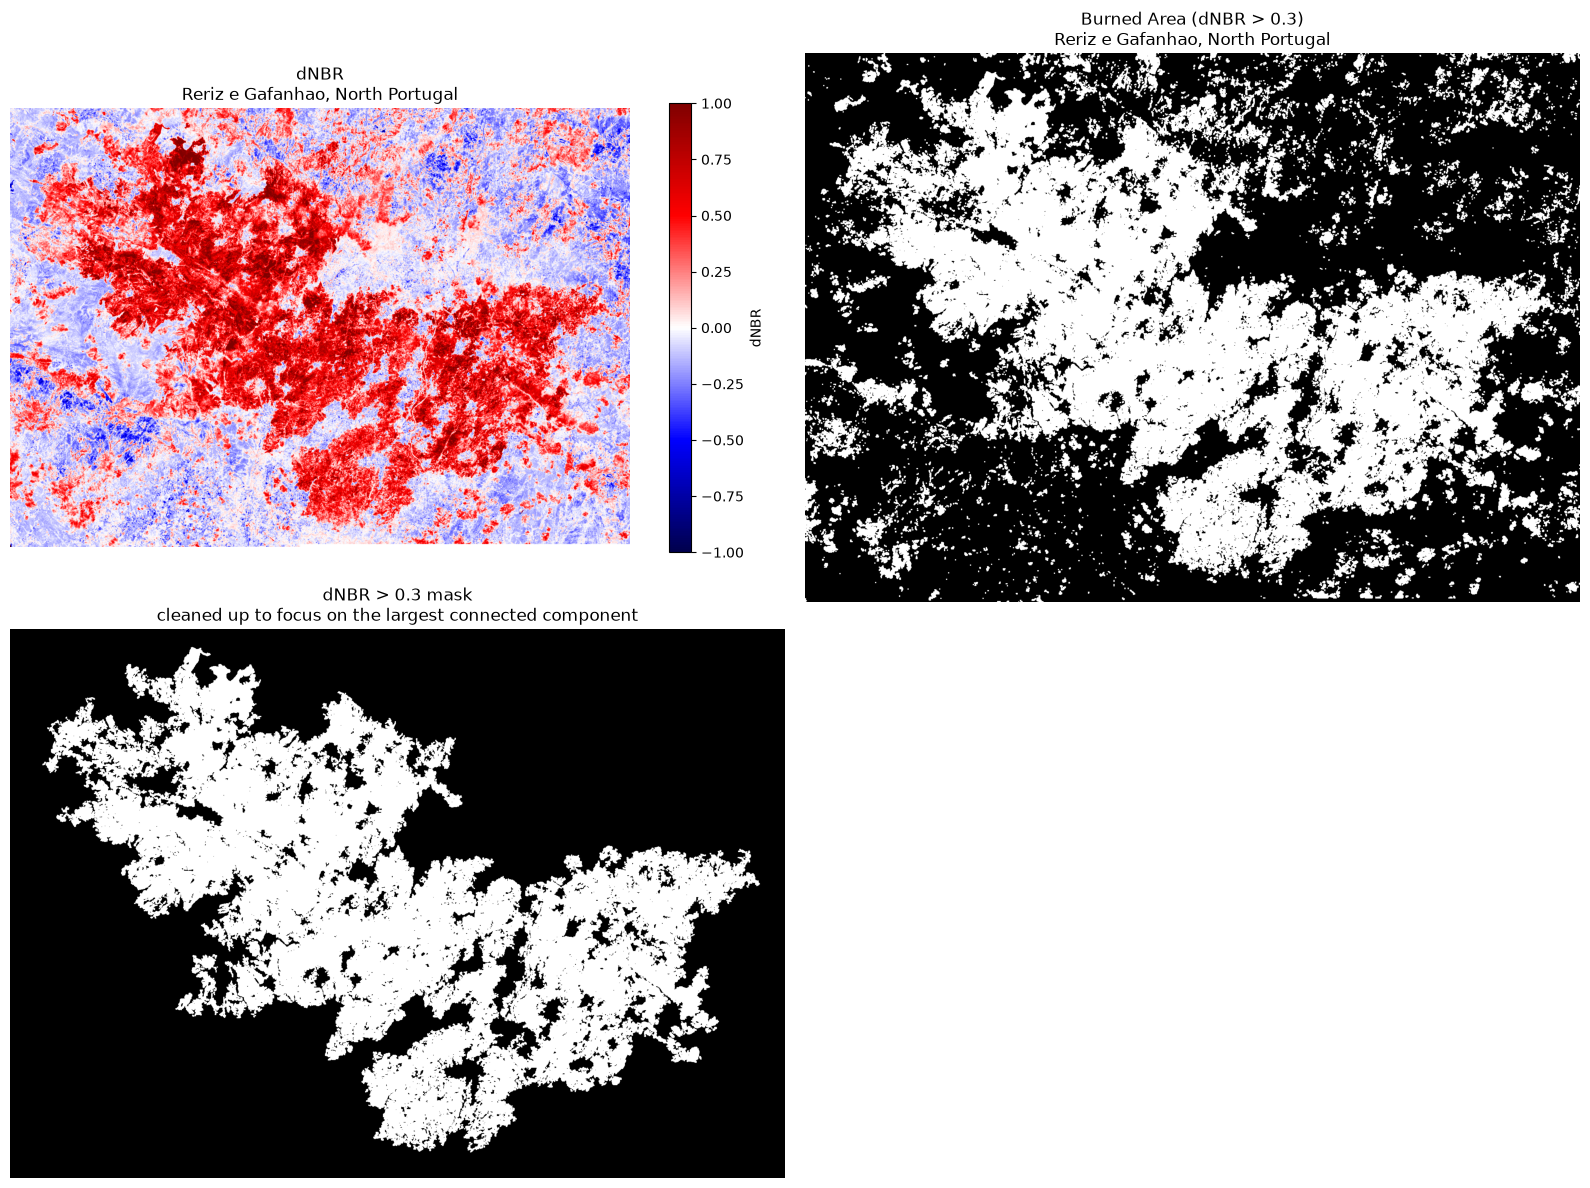

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax1, ax2, ax3, ax4 = axes.flat
fig.delaxes(ax4)

im1 = ax1.imshow(dnbr_gtiff, cmap="seismic", vmin=-1, vmax=1)
fig.colorbar(im1, ax=ax1, label="dNBR", shrink=0.8)
ax1.set_title(f"dNBR\n{current_params['location_name']}")
ax1.axis("off")

ax2.imshow(mask_gtif, cmap="gray")
ax2.set_title(f"Burned Area (dNBR > {burn_threshold_default})\n{current_params['location_name']}")
ax2.axis("off")

ax3.imshow(clean_mask, cmap="gray")
ax3.set_title(f"dNBR > {burn_threshold_default} mask\ncleaned up to focus on the largest connected component")
ax3.axis("off")

plt.tight_layout()
plt.show()

In [16]:
clean_mask_file = f"clean_mask_{location_slug}.tif"
profile = mask_profile.copy()
profile.update(dtype=clean_mask.dtype, count=1)

with rasterio.open(clean_mask_file, "w", **profile) as dst:
    dst.write(clean_mask, 1)

## 4. ML Vegetation Classification via Server-Side UDF

Random Forest training features are downloaded for the small set of NFI label points, then the
trained classifier is shipped to the backend as a UDF and applied to the full raster with
`reduce_dimension` — classification of every pixel happens server-side, and only the resulting
single-band GeoTIFF is downloaded.

### 4.1 Load NFI Labels

In [ ]:
nfi_labels = geopandas.read_file("input_data/nfi_labels.geojson")
geojson_labels = json.loads(nfi_labels[["label", "geometry"]].to_json())

y_train_str = nfi_labels["label"].values.tolist()
label_names = sorted(set(y_train_str))  

In [18]:
def calculate_ndvi(data: openeo.rest.datacube.DataCube):
    """Compute the Normalized Difference Vegetation Index (NDVI) from the B04 and B08 bands.

    Args:
        data: Cube with bands B04 (red) and B08 (near-infrared), in that order.

    Returns:
        openeo.rest.datacube.DataCube: The NDVI cube, (B08 - B04) / (B08 + B04).
    """
    B04, B08 = data[0], data[1]
    ndvi = (B08 - B04) / (B08 + B04)
    return ndvi


def add_ndvi_band(cube: openeo.rest.datacube.DataCube) -> openeo.rest.datacube.DataCube:
    """Append an NDVI band to an existing cube.

    Args:
        cube: Existing cube.

    Returns:
        openeo.rest.datacube.DataCube: The same cube with an additional 'NDVI' band
        appended (raw bands are kept, NDVI is an extra feature).
    """
    ndvi_cube = cube.reduce_dimension(dimension="bands", reducer=calculate_ndvi)
    ndvi_cube = ndvi_cube.add_dimension(name="bands", label="NDVI", type="bands")
    return cube.merge_cubes(ndvi_cube)

### 4.2 Download Spectral Features at Label Locations

In [21]:
res = 20
time_reduction = "monthly"

s2_train = load_and_sample(
    current_params["collection"].default,
    current_params["bounding_box"],
    current_params["time"],
    current_params["bands_ml"].default,
    current_params["cloud_cover"].default,
    res,
    time_reduction,
)
s2_train = add_ndvi_band(s2_train)

features_cube = s2_train.aggregate_spatial(geojson_labels, reducer="mean")

features_cube_resolved = param_manager.resolve(features_cube, current_params)

features_out_file = f"training_features_{location_slug}.json"
download_cube(features_cube_resolved, features_out_file, "JSON", batch=False)

with open(features_out_file) as f:
    raw_train = json.load(f)

# X_train_raw = np.array(raw_train, dtype=float)
X_train_raw = np.hstack(list(raw_train.values()))
y_train_raw = np.array(y_train_str)

# # Drop label points that landed on a nodata/cloud-masked pixel (aggregate_spatial returns
# # null -> NaN for those) — RandomForestClassifier can't fit on NaN features.
# valid_train = ~np.isnan(X_train_raw).any(axis=1)
# n_dropped = (~valid_train).sum()
# if n_dropped:
#     print(f"Dropping {n_dropped} of {len(valid_train)} label points with missing feature values")

X_train = X_train_raw

### 4.3 Validate Classifier on a Held-Out Split

Before shipping the classifier off to run server-side on the full raster, fit it on a train/test
split locally and check accuracy — section 4.4 retrains the classifier locally on the *full*
label set before shipping it to the UDF for deployment, but this gives a sense of expected
performance first.

In [22]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train_str, test_size=0.2, random_state=42, stratify=y_train_str
)
validation_clf = RandomForestClassifier(n_estimators=100, random_state=42)
validation_clf.fit(X_tr, y_tr)

print(classification_report(y_te, validation_clf.predict(X_te)))

                precision    recall  f1-score   support

    Eucalyptus       0.75      0.38      0.50        16
Maritime Pines       0.72      0.66      0.69        32
     Shrubland       0.73      0.87      0.79        55

      accuracy                           0.73       103
     macro avg       0.73      0.63      0.66       103
  weighted avg       0.73      0.73      0.72       103



### 4.4 Define ML UDF

The UDF uses the `apply_datacube` signature and is submitted to the backend as a code string. The
backend calls it once per spatial chunk of the S2 raster.

Inside the UDF:
1. Unpickle the trained `RandomForestClassifier` from `context`
2. Reshape the chunk into per-pixel feature vectors
3. Predict a class ID per pixel
4. Return the predicted class raster

The classifier is trained once, locally, on the full label set (next cell) and shipped to the
backend already trained — the UDF only performs inference, it does not retrain per chunk.

In [24]:
# Train the final classifier on the full cleaned training set (not just the validation split)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train_str)

# Serialize so it can be embedded in the UDF context (context must be JSON-serializable)
model_b64 = base64.b64encode(pickle.dumps(clf)).decode("utf-8")

In [25]:
udf_code = textwrap.dedent("""
    import base64
    import pickle

    import numpy as np
    import xarray as xr

    def apply_datacube(cube: xr.DataArray, context: dict) -> xr.DataArray:
        clf = pickle.loads(base64.b64decode(context["model"]))
        label_names = context["label_names"]
        class_to_int = {cls: float(i) for i, cls in enumerate(label_names)}

        arr = cube.values
        n_t, n_bands, height, width = arr.shape
        X_pred = arr.reshape(n_t * n_bands, -1).T
        valid  = ~np.isnan(X_pred).any(axis=1)

        preds_str  = np.full(height * width, "NoData", dtype=object)
        preds_str[valid] = clf.predict(X_pred[valid])
        preds_float = np.array([class_to_int.get(p, -1.0) for p in preds_str])

        return xr.DataArray(
            preds_float.reshape(1, height, width),
            dims=cube.dims[1:],
        )
""")

### 4.5 Submit Prediction Batch Job

`context` carries the trained classifier (base64-pickled in 4.4) plus the label names. The
prediction raster is processed entirely server-side — only the single-band classification
GeoTIFF is downloaded.

In [26]:
context = {
    "model": model_b64,             # base64-pickled RandomForestClassifier
    "label_names": label_names,
}

udf = UDF(code=udf_code, runtime="Python", context=context)

# Prediction cube stays server-side — UDF is applied along the bands dimension
s2_pred = load_and_sample(
    current_params["collection"].default,
    current_params["bounding_box"],
    current_params["time"],
    current_params["bands_ml"].default,
    current_params["cloud_cover"].default,
    res,
    time_reduction,
)
s2_pred = add_ndvi_band(s2_pred)
result = s2_pred.reduce_dimension(dimension="t", reducer=udf)

pred_out_folder = "udf_prediction"
os.makedirs(pred_out_folder, exist_ok=True)

result_resolved = param_manager.resolve(result, current_params)
download_cube(result_resolved, pred_out_folder, "GTiff")

# The backend names the downloaded asset itself (e.g. "openEO.tif") — rename it to a
# custom, predictable filename so downstream cells don't need to glob for it.
downloaded_tiff = glob.glob(f"{pred_out_folder}/*.tif")[0]
pred_tiff_file = os.path.join(pred_out_folder, f"udf_prediction_{location_slug}.tif")
os.replace(downloaded_tiff, pred_tiff_file)
print(f"Downloaded prediction raster: {pred_tiff_file}")

0:00:00 Job 'j-26072114073840b0a2e9e39f3d1cacbd': send 'start'
0:00:06 Job 'j-26072114073840b0a2e9e39f3d1cacbd': queued (progress 0%)
0:00:14 Job 'j-26072114073840b0a2e9e39f3d1cacbd': queued (progress 0%)
0:00:24 Job 'j-26072114073840b0a2e9e39f3d1cacbd': queued (progress 0%)
0:00:35 Job 'j-26072114073840b0a2e9e39f3d1cacbd': queued (progress 0%)
0:00:48 Job 'j-26072114073840b0a2e9e39f3d1cacbd': queued (progress 0%)
0:01:04 Job 'j-26072114073840b0a2e9e39f3d1cacbd': queued (progress 0%)
0:01:23 Job 'j-26072114073840b0a2e9e39f3d1cacbd': running (progress N/A)
0:01:45 Job 'j-26072114073840b0a2e9e39f3d1cacbd': running (progress N/A)
0:02:13 Job 'j-26072114073840b0a2e9e39f3d1cacbd': running (progress N/A)
0:02:47 Job 'j-26072114073840b0a2e9e39f3d1cacbd': running (progress N/A)
0:03:28 Job 'j-26072114073840b0a2e9e39f3d1cacbd': running (progress N/A)
0:04:19 Job 'j-26072114073840b0a2e9e39f3d1cacbd': running (progress N/A)
0:05:21 Job 'j-26072114073840b0a2e9e39f3d1cacbd': finished (progress 100%

## 5. Visualize Results

/var/folders/6n/l9czk0nj5hd1pnryp2mg3dr00000gn/T/ipykernel_62449/1994198306.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  pred_raster = src.read(1).astype(float)


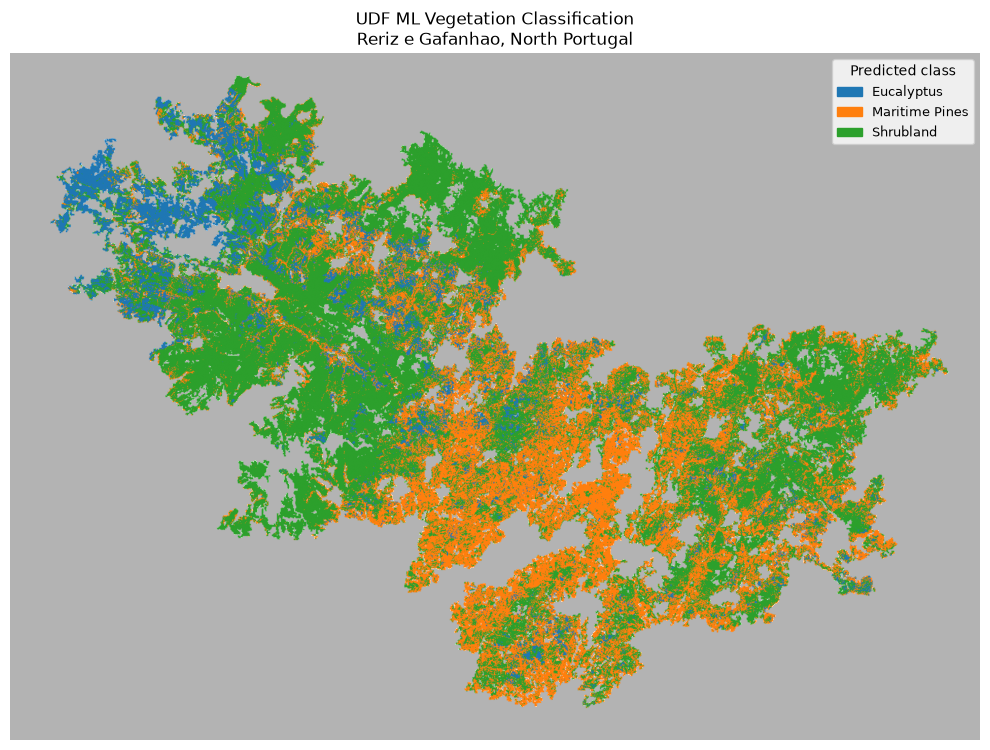

In [27]:
with rasterio.open(pred_tiff_file) as src:
    pred_raster = src.read(1).astype(float)

pred_raster[pred_raster < 0] = np.nan  # -1 -> NoData
pred_fire = np.where(clean_mask == 1, pred_raster, np.nan)

n_classes = len(label_names)
colors = [plt.get_cmap("tab10")(i) for i in range(n_classes)]
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=np.arange(-0.5, n_classes, 1), ncolors=n_classes)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(clean_mask, cmap="gray", interpolation="none", alpha=0.3)
ax.imshow(pred_fire, cmap=cmap, norm=norm)
legend_patches = [mpatches.Patch(color=colors[i], label=name) for i, name in enumerate(label_names)]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, title="Predicted class")
ax.set_title(f"UDF ML Vegetation Classification\n{current_params['location_name']}")
ax.axis("off")
plt.tight_layout()
plt.show()

In [28]:
fire_preds = pred_raster[clean_mask == 1]
fire_preds = fire_preds[~np.isnan(fire_preds)].astype(int)

print("Prediction counts in fire area:")
for i, name in enumerate(label_names):
    count = (fire_preds == i).sum()
    pct = 100 * count / len(fire_preds)
    print(f"  {name:<18} {count:>7,}  ({pct:.1f}%)")
print(f"  {'Total':<18} {len(fire_preds):>7,}")

Prediction counts in fire area:
  Eucalyptus          92,087  (11.5%)
  Maritime Pines     270,712  (33.7%)
  Shrubland          440,907  (54.9%)
  Total              803,706


## 6. CO₂ Emission Calculation

Each classified pixel from the UDF prediction covers 20 × 20 m (0.04 ha), so multiplying the per-class pixel count from section 4.5's prediction output by 0.04 gives the area each vegetation type covers within the burned area.

| Type | Pixel Count (20x20 m) | Area (ha) |
|---|---:|---:|
| Maritime Pine | 270,431 | 10,817.24 |
| Eucalyptus | 92,382 | 3,695.28 |
| Shrubland | 440,893 | 17,635.72 |

With the area each vegetation type covers now known, we can calculate the CO₂ emissions released by the fire using that area together with each type's biomass, combustion factor, and emission factor:

- L<sub>fire</sub> (Mg): the CO₂ emissions released by the fire, in megagrams (Mg) — equivalent to metric tons.
- Area (ha): the area the vegetation type takes up.
- M<sub>B</sub> (Mg/ha): how much biomass per hectare is available on average.
- C<sub>f</sub>: the combustion factor — how much of the available biomass typically burns.
- G<sub>ef</sub>: the emission factor — how much CO₂ is released per unit of biomass burned.

**Formula:**

<div style="text-align:center; font-size:1.4em; font-family: Cambria, 'Times New Roman', serif; margin: 0.5em 0 1em 0;">
<i>L</i><sub>fire</sub>&nbsp;=&nbsp;<i>A</i>&nbsp;×&nbsp;<i>M</i><sub>B</sub>&nbsp;×&nbsp;<i>C</i><sub>f</sub>&nbsp;×&nbsp;<i>G</i><sub>ef</sub><sub style="font-size:0.6em;">&nbsp;[3]</sub>
</div>

<table>
<thead>
<tr>
<th style="text-align:left">Type</th>
<th style="text-align:left">Ha</th>
<th style="text-align:left">M<sub>B</sub> (Mg/ha)</th>
<th style="text-align:left">C<sub>f</sub></th>
<th style="text-align:left">G<sub>ef</sub></th>
<th style="text-align:left">CO₂ (Mg)</th>
</tr>
</thead>
<tbody>
<tr>
<td>Maritime Pine</td>
<td style="text-align:right">10,817.24</td>
<td style="text-align:right">74.96 <sub>[1]</sub></td>
<td style="text-align:right">0.45 <sub>[3]</sub></td>
<td style="text-align:right">1.569 <sub>[3]</sub></td>
<td style="text-align:right">572,507.922</td>
</tr>
<tr>
<td>Eucalyptus</td>
<td style="text-align:right">3,695.28</td>
<td style="text-align:right">78.70 <sub>[2]</sub></td>
<td style="text-align:right">0.63 <sub>[3]</sub></td>
<td style="text-align:right">1.569 <sub>[3]</sub></td>
<td style="text-align:right">287,465.398</td>
</tr>
<tr>
<td>Shrubland</td>
<td style="text-align:right">17,635.72</td>
<td style="text-align:right">16.40 <sub>[2]</sub></td>
<td style="text-align:right">0.95 <sub>[3]</sub></td>
<td style="text-align:right">1.613 <sub>[3]</sub></td>
<td style="text-align:right">443,195.167</td>
</tr>
<tr>
<td><strong>Sum</strong></td>
<td style="text-align:right"></td>
<td style="text-align:right"></td>
<td style="text-align:right"></td>
<td style="text-align:right"></td>
<td style="text-align:right"><strong>1,303,168.487</strong></td>
</tr>
</tbody>
</table>

**References**

1. ICNF: IFN6 - Principais resultados - relatório sumário. Instituto da Conservação da Natureza e das Florestas, I.P., Lisboa (2019)
2. Alegria, C.: Aboveground biomass mapping and fire potential severity assessment: a case study for eucalypts and shrubland areas in the central inland region of Portugal. Forests 14(9), 1795 (2023). https://doi.org/10.3390/f14091795
3. Eggleston, H.S., Buendia, L., Miwa, K., Ngara, T., Tanabe, K. (eds.): 2006 IPCC Guidelines for National Greenhouse Gas Inventories. Institute for Global Environmental Strategies (IGES), Hayama, Japan (2006)